TASK 4: CONFIDENCE INTERVALS & BOOTSTRAP

📊 copiesSold
  n = 1500
  Mean = 141482.570
  95% CI: (84158.227, 198806.913)
  Using z (normal) distribution

📊 price
  n = 1500
  Mean = 17.520
  95% CI: (16.880, 18.160)
  Using z (normal) distribution

📊 revenue
  n = 1500
  Mean = 2632381.983
  95% CI: (1225015.537, 4039748.428)
  Using z (normal) distribution

📊 avgPlaytime
  n = 1500
  Mean = 12.563
  95% CI: (11.473, 13.653)
  Using z (normal) distribution

📊 reviewScore
  n = 1500
  Mean = 76.201
  95% CI: (74.971, 77.432)
  Using z (normal) distribution

📊 revenue_per_copy
  n = 1500
  Mean = 14.367
  95% CI: (13.777, 14.957)
  Using z (normal) distribution

📊 copiesSold (Bootstrap)
  Original mean: 141482.570
  Bootstrap mean: 141926.861
  95% Bootstrap CI: (91912.383, 205218.238)

📊 price (Bootstrap)
  Original mean: 17.520
  Bootstrap mean: 17.520
  95% Bootstrap CI: (16.882, 18.173)

📊 revenue (Bootstrap)
  Original mean: 2632381.983
  Bootstrap mean: 2623191.604
  95% Bootstrap C

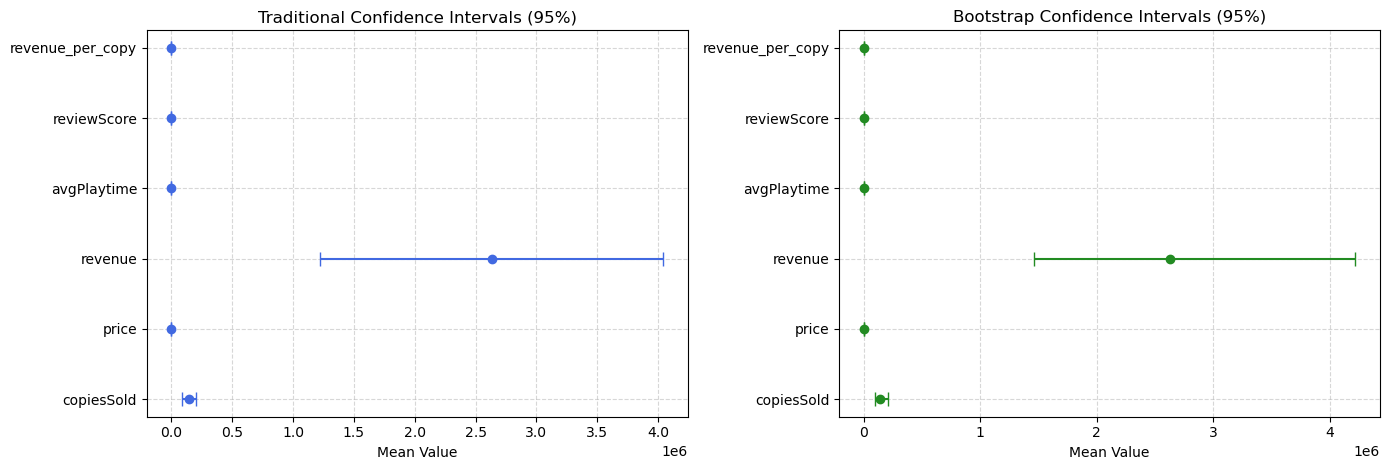

✅ Confidence interval visualizations saved.


In [2]:
import sys
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import DataLoader

# 1. Load Cleaned Dataset
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

print("=" * 60)
print("TASK 4: CONFIDENCE INTERVALS & BOOTSTRAP")
print("=" * 60)

# Drop non-analytical unique identifier columns if present
exclude_cols = ['steamId', 'id', 'game_id']
numeric_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col not in exclude_cols]

# ==================== 1. CONFIDENCE INTERVALS ====================

def calculate_confidence_interval(data, confidence=0.95):
    """Calculate traditional confidence interval for mean."""
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)
    
    if n >= 30:
        z_score = stats.norm.ppf((1 + confidence) / 2)
        margin = z_score * se
        dist = 'z (normal)'
    else:
        t_score = stats.t.ppf((1 + confidence) / 2, df=n-1)
        margin = t_score * se
        dist = 't (Student\'s)'
    
    return {
        'n': n,
        'mean': mean,
        'std': std,
        'se': se,
        'margin': margin,
        'lower': mean - margin,
        'upper': mean + margin,
        'distribution': dist
    }

ci_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        ci_results[col] = calculate_confidence_interval(data)
        
        print(f"\n📊 {col}")
        print(f"  n = {ci_results[col]['n']}")
        print(f"  Mean = {ci_results[col]['mean']:.3f}")
        print(f"  95% CI: ({ci_results[col]['lower']:.3f}, {ci_results[col]['upper']:.3f})")
        print(f"  Using {ci_results[col]['distribution']} distribution")

# ==================== 2. BOOTSTRAP ====================

def bootstrap_ci(data, statistic=np.mean, n_bootstrap=10000, confidence=0.95):
    """Calculate non-parametric bootstrap confidence interval."""
    n = len(data)
    bootstrap_stats = []
    
    # Resample with replacement
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats.append(statistic(sample))
    
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, (alpha / 2) * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha / 2) * 100)
    
    return {
        'original': statistic(data),
        'bootstrap_mean': np.mean(bootstrap_stats),
        'bootstrap_std': np.std(bootstrap_stats),
        'lower': lower,
        'upper': upper,
        'confidence': confidence
    }

bootstrap_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        bootstrap_results[col] = bootstrap_ci(data)
        
        print(f"\n📊 {col} (Bootstrap)")
        print(f"  Original mean: {bootstrap_results[col]['original']:.3f}")
        print(f"  Bootstrap mean: {bootstrap_results[col]['bootstrap_mean']:.3f}")
        print(f"  95% Bootstrap CI: ({bootstrap_results[col]['lower']:.3f}, {bootstrap_results[col]['upper']:.3f})")

# ==================== 3. COMPARE CI METHODS ====================

print("\n" + "=" * 60)
print("COMPARISON: Traditional CI vs Bootstrap CI")
print("=" * 60)

comparison_data = []
for col in numeric_cols:
    if col in ci_results and col in bootstrap_results:
        comparison_data.append({
            'column': col,
            'mean': ci_results[col]['mean'],
            'ci_lower': ci_results[col]['lower'],
            'ci_upper': ci_results[col]['upper'],
            'bootstrap_lower': bootstrap_results[col]['lower'],
            'bootstrap_upper': bootstrap_results[col]['upper'],
            'ci_width': ci_results[col]['upper'] - ci_results[col]['lower'],
            'bootstrap_width': bootstrap_results[col]['upper'] - bootstrap_results[col]['lower']
        })

comparison_df = pd.DataFrame(comparison_data)
# Direct output path relative to root project structure
output_csv = project_root / 'reports' / 'ci_comparison.csv'
output_csv.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(output_csv, index=False)

print(f"\n✅ Confidence interval results saved to '{output_csv}'")

# ================= 4. VISUALIZE CONFIDENCE INTERVALS =================

def plot_confidence_intervals(ci_results, bootstrap_results):
    """Plot confidence intervals side-by-side for numeric attributes."""
    cols = list(ci_results.keys())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(cols) * 0.8)))
    
    # Traditional CIs
    for i, col in enumerate(cols):
        ci = ci_results[col]
        ax1.errorbar(ci['mean'], i, 
                    xerr=ci['margin'], 
                    fmt='o', capsize=5, color='royalblue')
    ax1.set_yticks(range(len(cols)))
    ax1.set_yticklabels(cols)
    ax1.set_xlabel('Mean Value')
    ax1.set_title('Traditional Confidence Intervals (95%)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Bootstrap CIs
    for i, col in enumerate(cols):
        if col in bootstrap_results:
            boot = bootstrap_results[col]
            err_lower = boot['original'] - boot['lower']
            err_upper = boot['upper'] - boot['original']
            ax2.errorbar(boot['original'], i, 
                        xerr=[[err_lower], [err_upper]], 
                        fmt='o', capsize=5, color='forestgreen')
    ax2.set_yticks(range(len(cols)))
    ax2.set_yticklabels(cols)
    ax2.set_xlabel('Mean Value')
    ax2.set_title('Bootstrap Confidence Intervals (95%)')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    output_fig = project_root / 'reports' / 'figures' / 'confidence_intervals_comparison.png'
    output_fig.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_fig, dpi=300, bbox_inches='tight')
    plt.show()

# Export figure
if ci_results and bootstrap_results:
    plot_confidence_intervals(ci_results, bootstrap_results)

print("✅ Confidence interval visualizations saved.")